<a href="https://colab.research.google.com/github/sharvaripd/DL-/blob/main/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Solving Churn Modelling using ANN
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense



In [ ]:
df=pd.read_csv("Churn_Modelling.csv")
df.head()


FileNotFoundError: [Errno 2] No such file or directory: 'Churn_Modelling.csv'

In [ ]:
# Select input and output
x= df.iloc[:,3:-1]
y= df.iloc[:,-1]
print(x.head())
print(y.head())




   CreditScore Geography  Gender  ...  HasCrCard  IsActiveMember  EstimatedSalary
0          619    France  Female  ...          1               1        101348.88
1          608     Spain  Female  ...          0               1        112542.58
2          502    France  Female  ...          1               0        113931.57
3          699    France  Female  ...          0               0         93826.63
4          850     Spain  Female  ...          1               1         79084.10

[5 rows x 10 columns]
0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder
# Data Preprocessing
x['Geography']=LabelEncoder().fit_transform(x['Geography'])
x['Gender']=LabelEncoder().fit_transform(x['Gender'])
print(x.head())

   CreditScore  Geography  Gender  ...  HasCrCard  IsActiveMember  EstimatedSalary
0          619          0       0  ...          1               1        101348.88
1          608          2       0  ...          0               1        112542.58
2          502          0       0  ...          1               0        113931.57
3          699          0       0  ...          0               0         93826.63
4          850          2       0  ...          1               1         79084.10

[5 rows x 10 columns]


In [ ]:
# Train Test Split of the data
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape,x_test.shape)
print(y_train.shape,y_test.shape)

NameError: name 'train_test_split' is not defined

In [ ]:
# Feature Scaling
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)


In [ ]:
# Building ANN
ann=Sequential()
ann.add(Dense(units=6,activation='relu')) # Unit represents the number of perceptrons
ann.add(Dense(units=6,activation='relu')) # Hidden Layer
ann.add(Dense(units=1,activation='sigmoid')) # Output Layer

In [ ]:
#Compile
ann.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
# Prediction
y_pred=ann.predict(x_test)
y_pred=(y_pred>0.5)
print(y_pred[0:10])

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step
[[False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [ True]]


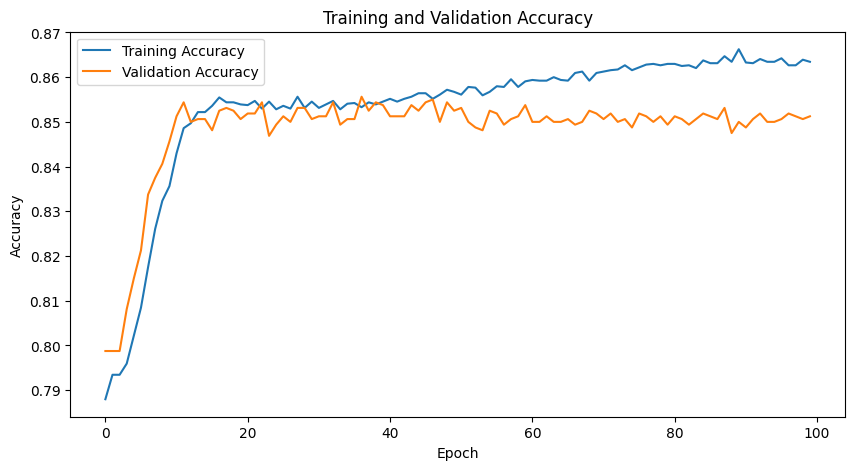

In [ ]:
# Accuracy Graphy
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

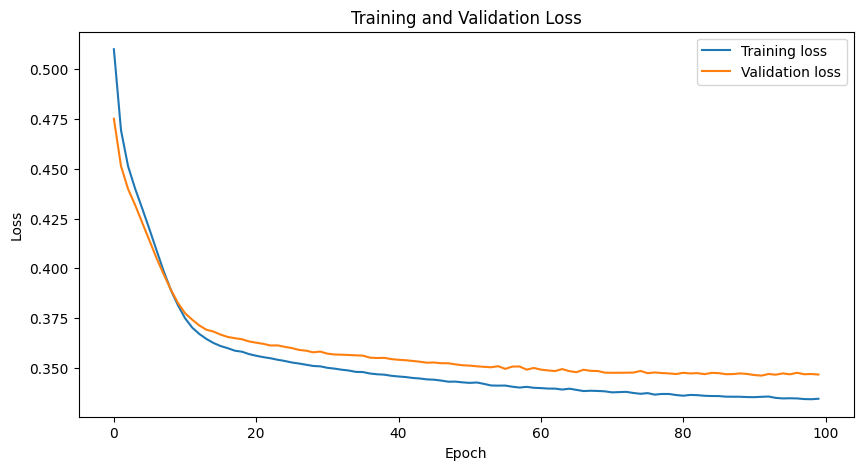

In [ ]:
# Loss Graph
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'],label='Training loss')
plt.plot(history.history['val_loss'],label='Validation loss')
plt.title('Training and Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()